# Random Forest Model

This section focuses on building a Random Forest classification model to predict whether a breast tumor is benign or malignant.

The preprocessed dataset is used for model development. The data is divided into training, validation, and testing sets.

The training set is used to fit the model, the validation set is used for model selection and hyperparameter tuning, and the testing set is reserved for final evaluation.

## 1. Importing Required Libraries

The required libraries are imported for building, tuning, and evaluating the Random Forest classification model.

In [5]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 2. Loading the Dataset



In [8]:
data_path = "wdbc.data"

df = pd.read_csv(data_path, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.1 Assigning Column Names

The original `wdbc.data` file does not contain column headers. The identifier, diagnosis variable, and 30 diagnostic feature names are assigned so that the data can be processed consistently with the previous stages.

In [11]:
columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df.columns = columns

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Preparing Features and Target

The identifier column is excluded because it does not contain diagnostic information.

The `diagnosis` column is used as the target variable, where:
- `B` represents Benign
- `M` represents Malignant

The remaining 30 diagnostic measurements are used as input features.

In [14]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


### 3.1 Encoding the Target Variable

The diagnosis labels are categorical values (`B` for Benign and `M` for Malignant).

For Random Forest classification, the target is converted into binary numerical labels:
- `0` = Benign
- `1` = Malignant

This encoding also makes it possible to calculate malignant-class probabilities and evaluation metrics consistently.

In [17]:
y = y.map({"B": 0, "M": 1})

print("Encoded target distribution:")
print(y.value_counts().sort_index())

Encoded target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


## 4. Reproducing the Train/Validation/Test Split

The train, validation, and test split was defined during the preprocessing stage.

Since each notebook has an independent Python environment, the same stratified split is reproduced here using the fixed random state of 42.

The test set remains separate and will be used only for final evaluation.

In [20]:
from sklearn.model_selection import train_test_split

# Reproduce the same 80/10/10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (455, 30) (455,)
Validation set: (57, 30) (57,)
Test set: (57, 30) (57,)


## 5. Baseline Random Forest Model

A baseline Random Forest classifier is trained using the training dataset.

The baseline model provides a reference point before hyperparameter tuning. Random Forest does not require feature scaling, so the original feature values are used.

A fixed random state of 42 is used to make the model results reproducible.

In [23]:
# Creating the baseline Random Forest model
baseline_rf = RandomForestClassifier(
    random_state=42
)

# Training the model
baseline_rf.fit(X_train, y_train)

print("Baseline Random Forest model trained successfully.")

Baseline Random Forest model trained successfully.


### 5.1 Baseline Validation Evaluation

The baseline Random Forest is evaluated on the validation set before hyperparameter tuning.

The validation set is used to understand the initial model performance and establish a reference for comparison with the tuned model.

The test set remains untouched at this stage.

In [32]:
# Generate predictions on the validation set
y_val_pred_baseline = baseline_rf.predict(X_val)
y_val_proba_baseline = baseline_rf.predict_proba(X_val)[:, 1]

print("Baseline Validation Metrics")
print("--------------------------------")

print(f"Accuracy : {accuracy_score(y_val, y_val_pred_baseline) * 100:.2f}%")
print(f"Precision: {precision_score(y_val, y_val_pred_baseline) * 100:.2f}%")
print(f"Recall   : {recall_score(y_val, y_val_pred_baseline) * 100:.2f}%")
print(f"F1 Score : {f1_score(y_val, y_val_pred_baseline) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_proba_baseline) * 100:.2f}%")

Baseline Validation Metrics
--------------------------------
Accuracy : 98.25%
Precision: 100.00%
Recall   : 95.24%
F1 Score : 97.56%
ROC-AUC  : 99.14%


## 6. Random Forest Hyperparameter Tuning

The Random Forest model is tuned to identify a suitable combination of hyperparameters.

The tuning process follows the parameter ranges specified in the project problem statement. ROC-AUC is used as the primary selection metric because it evaluates the model's ability to distinguish between benign and malignant cases across classification thresholds.

The validation set remains separate from the cross-validation process and will be used later for operating-threshold analysis.

In [37]:
from sklearn.model_selection import GridSearchCV

### 6.1 Defining the Hyperparameter Grid

The following Random Forest hyperparameters are tuned:

- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_split`: Minimum samples required to split an internal node
- `min_samples_leaf`: Minimum samples required at a leaf node
- `max_features`: Number of features considered when looking for the best split
- `class_weight`: Weighting strategy for the classes

A fixed random state of 42 is used for reproducibility.

In [40]:
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
    "class_weight": [None, "balanced"]
}

print(
    "Number of parameter combinations:",
    3 * 4 * 3 * 3 * 3 * 2
)

Number of parameter combinations: 648


### 6.2 Running GridSearchCV

GridSearchCV evaluates all combinations in the specified hyperparameter grid using 5-fold cross-validation on the training data.

ROC-AUC is used as the scoring metric because the project emphasizes strong class discrimination while protecting malignant-case detection.

The validation and test sets are not used during this tuning process.

In [43]:
rf_for_tuning = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Hyperparameter tuning completed.


### 6.3 Best Hyperparameters

The best-performing hyperparameter combination identified by GridSearchCV is extracted.

The model was selected based on the highest mean cross-validation ROC-AUC.

In [46]:
print("Best Cross-Validation ROC-AUC:")
print(f"{grid_search.best_score_ * 100:.2f}%")

print("\nBest Hyperparameters:")
print(grid_search.best_params_)

Best Cross-Validation ROC-AUC:
99.15%

Best Hyperparameters:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 6.4 Tuned Model Validation Evaluation

The best Random Forest model identified by GridSearchCV is evaluated on the validation set.

This evaluation is used to compare the tuned model with the baseline model before making the final threshold decision.

The test set remains untouched and will be reserved for the final evaluation.

In [49]:
# Best model identified by GridSearchCV
best_rf = grid_search.best_estimator_

# Generate validation predictions
y_val_pred_tuned = best_rf.predict(X_val)
y_val_proba_tuned = best_rf.predict_proba(X_val)[:, 1]

print("Tuned Random Forest Validation Metrics")
print("----------------------------------------")

print(f"Accuracy : {accuracy_score(y_val, y_val_pred_tuned) * 100:.2f}%")
print(f"Precision: {precision_score(y_val, y_val_pred_tuned) * 100:.2f}%")
print(f"Recall   : {recall_score(y_val, y_val_pred_tuned) * 100:.2f}%")
print(f"F1 Score : {f1_score(y_val, y_val_pred_tuned) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_proba_tuned) * 100:.2f}%")

Tuned Random Forest Validation Metrics
----------------------------------------
Accuracy : 98.25%
Precision: 100.00%
Recall   : 95.24%
F1 Score : 97.56%
ROC-AUC  : 99.74%


## 7. Threshold Analysis

Random Forest provides a probability of malignancy for each observation.

By default, a probability threshold of 0.50 is used to classify an observation as malignant. However, changing the threshold can affect the balance between false negatives and false positives.

Because missing a malignant case is an important error in this learning exercise, different thresholds are examined using the validation set.

The validation set is used for threshold selection, while the test set remains untouched.

In [52]:
thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba_tuned >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred_threshold),
        "Recall": recall_score(y_val, y_val_pred_threshold),
        "F1 Score": f1_score(y_val, y_val_pred_threshold),
        "Accuracy": accuracy_score(y_val, y_val_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score,Accuracy
0,0.30,0.952381,0.952381,0.952381,0.964912
1,0.35,0.952381,0.952381,0.952381,0.964912
2,0.40,0.952381,0.952381,0.952381,0.964912
3,0.45,0.952381,0.952381,0.952381,0.964912
4,0.50,1.000000,0.952381,0.975610,0.982456
5,0.55,1.000000,0.904762,0.950000,0.964912
6,0.60,1.000000,0.857143,0.923077,0.947368
7,0.65,1.000000,0.809524,0.894737,0.929825
8,0.70,1.000000,0.761905,0.864865,0.912281


### 7.1 Selected Classification Threshold

Based on the validation-set threshold analysis, a probability threshold of 0.50 is selected.

At this threshold, the model achieves 95.24% recall for malignant cases, 100% precision, 97.56% F1 score, and 98.25% accuracy.

Lower thresholds did not improve malignant recall but resulted in lower precision and accuracy. Higher thresholds increased the risk of false negatives by reducing malignant recall.

Therefore, 0.50 is retained as the operating threshold for the final evaluation.

In [55]:
selected_threshold = 0.50

y_val_pred_final = (
    y_val_proba_tuned >= selected_threshold
).astype(int)

print("Selected Threshold:", selected_threshold)
print()
print("Validation Metrics at Selected Threshold")
print("------------------------------------------")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred_final) * 100:.2f}%")
print(f"Precision: {precision_score(y_val, y_val_pred_final) * 100:.2f}%")
print(f"Recall   : {recall_score(y_val, y_val_pred_final) * 100:.2f}%")
print(f"F1 Score : {f1_score(y_val, y_val_pred_final) * 100:.2f}%")

Selected Threshold: 0.5

Validation Metrics at Selected Threshold
------------------------------------------
Accuracy : 98.25%
Precision: 100.00%
Recall   : 95.24%
F1 Score : 97.56%


## 8. Final Test Evaluation

The tuned Random Forest model is evaluated on the previously held-out test set.

The test set has not been used for model training, hyperparameter tuning, or threshold selection. It is used only once at this stage to provide an unbiased estimate of final model performance.

The selected classification threshold of 0.50 is applied to the predicted probability of malignancy.

In [62]:
# Generate test-set probabilities
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

# Apply the selected threshold
y_test_pred = (
    y_test_proba >= selected_threshold
).astype(int)

print("Final Test Metrics")
print("-------------------")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_test_pred) * 100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_test_pred) * 100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_test_pred) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba) * 100:.2f}%")

Final Test Metrics
-------------------
Accuracy : 96.49%
Precision: 100.00%
Recall   : 90.48%
F1 Score : 95.00%
ROC-AUC  : 99.74%


### 8.1 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for the benign and malignant classes.

For this project:

- True Negative (TN): Benign cases correctly classified as benign
- False Positive (FP): Benign cases incorrectly classified as malignant
- False Negative (FN): Malignant cases incorrectly classified as benign
- True Positive (TP): Malignant cases correctly classified as malignant

False negatives are particularly important because they represent malignant cases that were not detected by the model.

In [65]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[36  0]
 [ 2 19]]


### 8.2 Visual Confusion Matrix

A visual confusion matrix is created to make the model's classification results easier to interpret.

The rows represent the actual classes and the columns represent the predicted classes.

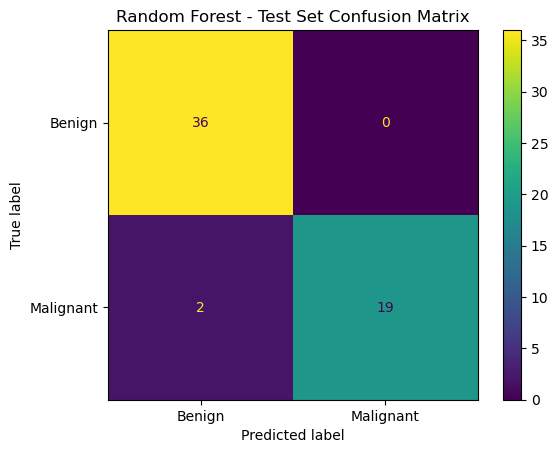

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Random Forest - Test Set Confusion Matrix")
plt.show()

### 8.3 Classification Report

The classification report provides class-level precision, recall, and F1-score for the final Random Forest model on the test set.

The malignant-class recall is particularly important because it measures how many of the actual malignant cases were correctly identified.

In [75]:
print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)

Classification Report
---------------------
              precision    recall  f1-score   support

      Benign     0.9474    1.0000    0.9730        36
   Malignant     1.0000    0.9048    0.9500        21

    accuracy                         0.9649        57
   macro avg     0.9737    0.9524    0.9615        57
weighted avg     0.9668    0.9649    0.9645        57



### 8.4 ROC Curve

The Receiver Operating Characteristic (ROC) curve shows the relationship between the true positive rate and false positive rate across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to distinguish between benign and malignant cases.

The ROC curve is calculated using the predicted probability of malignancy from the held-out test set.

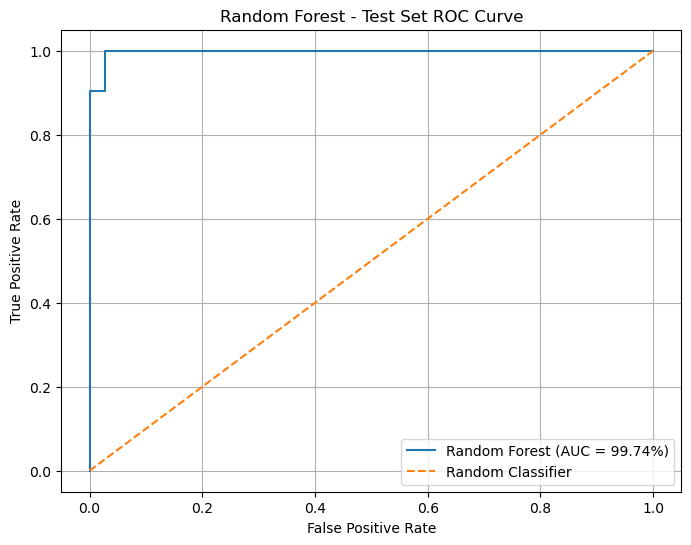

In [80]:
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_test_proba
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {test_roc_auc * 100:.2f}%)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - Test Set ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## 9. Error Analysis

Error analysis is performed to understand the cases that were incorrectly classified by the final Random Forest model.

The analysis focuses on false negatives and false positives because these errors provide useful information about the model's limitations.

On the held-out test set, the model produced two false negatives and no false positives.

### 9.1 Identifying Misclassified Test Cases

The misclassified test observations are identified using their original feature values, actual diagnosis, predicted diagnosis, and predicted probability of malignancy.

In [84]:
error_analysis_df = X_test.copy()

error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = y_test_pred
error_analysis_df["Malignancy_Probability"] = y_test_proba

error_analysis_df["Actual_Label"] = error_analysis_df["Actual"].map({
    0: "Benign",
    1: "Malignant"
})

error_analysis_df["Predicted_Label"] = error_analysis_df["Predicted"].map({
    0: "Benign",
    1: "Malignant"
})

misclassified = error_analysis_df[
    error_analysis_df["Actual"] != error_analysis_df["Predicted"]
]

misclassified[
    ["Actual_Label", "Predicted_Label", "Malignancy_Probability"]
]

,Actual_Label,Predicted_Label,Malignancy_Probability
385,Malignant,Benign,0.265926
86,Malignant,Benign,0.281255


### 9.2 Comparing Misclassified Cases with Class Averages

The feature values of the false-negative cases are compared with the average feature values of malignant and benign cases in the test set.

This helps identify which diagnostic measurements may have contributed to the difficult classification cases. The analysis is descriptive and does not imply clinical significance.

In [89]:
feature_columns = [
    col for col in X_test.columns
]

false_negatives = error_analysis_df[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0)
]

test_class_means = X_test.copy()
test_class_means["Diagnosis"] = y_test.values

class_means = test_class_means.groupby("Diagnosis").mean().T
class_means.columns = ["Benign_Mean", "Malignant_Mean"]

fn_comparison = false_negatives[feature_columns].T
fn_comparison.columns = [
    f"FN_Case_{idx}" for idx in false_negatives.index
]

comparison_table = pd.concat(
    [class_means, fn_comparison],
    axis=1
)

comparison_table.head(30)

,Benign_Mean,Malignant_Mean,FN_Case_385,FN_Case_86
radius_mean,12.186556,17.147143,14.600000,14.480000
texture_mean,18.219722,20.921429,23.290000,21.460000
perimeter_mean,78.515278,113.433810,93.970000,94.250000
area_mean,463.044444,938.990476,664.700000,648.200000
smoothness_mean,0.095438,0.103727,0.086820,0.094440
compactness_mean,0.089517,0.148670,0.066360,0.099470
concavity_mean,0.048647,0.163093,0.083900,0.120400
concave_points_mean,0.028024,0.089408,0.052710,0.049380
symmetry_mean,0.176028,0.196114,0.162700,0.207500
fractal_dimension_mean,0.063682,0.063326,0.054160,0.056360


### 9.3 False-Negative Pattern Summary

The two false-negative cases show several feature values that are closer to the benign-class average than to the malignant-class average.

In particular, measurements related to radius, perimeter, and area are substantially lower than the average values observed for malignant cases in the test set.

This suggests that these observations contain feature patterns that are more difficult for the Random Forest to distinguish from benign cases.

The model assigned malignancy probabilities of approximately 26.59% and 28.13% to these two cases, both below the selected classification threshold of 0.50.

These findings describe model behavior on the test set and should not be interpreted as clinical conclusions.

### 9.4 Error Summary

The final model produced two false negatives and no false positives on the held-out test set.

False negatives are particularly important for this project because they represent malignant observations that were classified as benign.

The false-negative cases had predicted malignancy probabilities below the selected threshold, indicating that the model was relatively confident in the incorrect benign classification.

In [93]:
error_summary = pd.DataFrame({
    "Error Type": ["False Negatives", "False Positives"],
    "Count": [
        ((y_test == 1) & (y_test_pred == 0)).sum(),
        ((y_test == 0) & (y_test_pred == 1)).sum()
    ]
})

error_summary

,Error Type,Count
0,False Negatives,2
1,False Positives,0


### 9.5 Error Analysis Recommendations

The error analysis indicates that the model's main error type is false negatives, where malignant observations were classified as benign.

The following steps could help reduce this type of error in future iterations:

1. Evaluate additional classification thresholds on the validation set when the cost of false negatives is considered more important.

2. Investigate class-weight settings during hyperparameter tuning to give greater importance to the malignant class.

3. Perform additional feature analysis to understand which diagnostic measurements contribute most to difficult classifications.

4. Evaluate model performance using repeated or stratified cross-validation to assess the stability of the results.

5. Investigate the misclassified observations in greater detail and assess whether additional representative training data could improve the model.

These suggestions are intended as machine-learning improvements and do not imply clinical deployment or diagnostic use.

## 10. Saving the Final Random Forest Model

The tuned Random Forest model is saved so that it can be reused later without retraining.

The saved model will also be used in the inference script required for the project.

In [97]:
import joblib

# Save the final tuned Random Forest model
joblib.dump(best_rf, "rf_model.joblib")

print("Final Random Forest model saved successfully as 'rf_model.joblib'.")

Final Random Forest model saved successfully as 'rf_model.joblib'.
